In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi, sqrt, exp

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",  # comment out if unavailable
    "font.family": "serif",
    "font.serif": ["Times"],
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 2.2,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "legend.frameon": False,
    "legend.handlelength": 2.0,
    "legend.handletextpad": 0.5,
    "legend.borderaxespad": 0.6,
    "legend.fontsize": 20,
})

In [3]:
a1 = np.array([1 + sqrt(2), 0.0], dtype=float)
a2 = np.array([0.0, 1 + sqrt(2)], dtype=float)


def _k_components(k):
    k = np.asarray(k, dtype=float).reshape(2)
    return float(k[0]), float(k[1])


def ham(k, t2):
    kx, ky = _k_components(k)
    t = 1.0
    k_a1 = kx * a1[0] + ky * a1[1]
    k_a2 = kx * a2[0] + ky * a2[1]
    return np.array([
        [0.0, t, t * exp(1j * k_a2) + t2, t],
        [t, 0.0, t, t * exp(-1j * k_a1) + t2],
        [t * exp(-1j * k_a2) + t2, t, 0.0, t],
        [t, t * exp(1j * k_a1) + t2, t, 0.0]
    ], dtype=complex)


def dH_dkx(k):
    kx, ky = _k_components(k)
    k_a1 = kx * a1[0] + ky * a1[1]
    return np.array([
        [0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, -1j * a1[0] * exp(-1j * k_a1)],
        [0.0, 0.0, 0.0, 0.0],
        [0.0, 1j * a1[0] * exp(1j * k_a1), 0.0, 0.0]
    ], dtype=complex)


def dH_dky(k):
    kx, ky = _k_components(k)
    k_a2 = kx * a2[0] + ky * a2[1]
    return np.array([
        [0.0, 0.0, 1j * a2[1] * exp(1j * k_a2), 0.0],
        [0.0, 0.0, 0.0, 0.0],
        [-1j * a2[1] * exp(-1j * k_a2), 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0]
    ], dtype=complex)


def _E(eps, mu, Delta):
    xi = eps - mu
    return np.sqrt(xi * xi + Delta * Delta)


def stiffness_at_k(k, t2, mu, Delta, eps_reg=1e-12):
    evals, evecs = np.linalg.eigh(ham(k, t2))
    vx = dH_dkx(k)
    vy = dH_dky(k)

    Vx = evecs.conj().T @ vx @ evecs
    Vy = evecs.conj().T @ vy @ evecs

    nb = len(evals)
    Dconv = 0.0
    Dgeom = 0.0

    for m in range(nb):
        Em = _E(evals[m], mu, Delta)
        vmx = float(np.real(Vx[m, m]))
        vmy = float(np.real(Vy[m, m]))
        Dconv += (Delta * Delta) * (vmx * vmx + vmy * vmy) / (Em**3)

    for m in range(nb):
        Em = _E(evals[m], mu, Delta)
        for n in range(nb):
            if n == m:
                continue

            En = _E(evals[n], mu, Delta)

            de = float(evals[m] - evals[n])
            sden = float(evals[m] + evals[n] - 2 * mu)
            dInvE = 1.0 / Em - 1.0 / En

            if abs(de) < eps_reg and abs(sden) < eps_reg:
                eps_avg = 0.5 * float(evals[m] + evals[n])
                xi = eps_avg - mu
                Eavg = np.sqrt(xi * xi + Delta * Delta)
                s = -1.0 / (2.0 * Eavg**3)
            else:
                if abs(de) < eps_reg:
                    de_eff = eps_reg if de >= 0 else -eps_reg
                else:
                    de_eff = de

                if abs(sden) < eps_reg:
                    sden_eff = eps_reg if sden >= 0 else -eps_reg
                else:
                    sden_eff = sden

                s = dInvE / (de_eff * sden_eff)

            vx_nm = Vx[n, m]
            vy_nm = Vy[n, m]
            off2 = abs(vx_nm)**2 + abs(vy_nm)**2

            Dgeom += (-2.0) * (Delta * Delta) * off2 * s

    return float(np.real(Dconv)), float(np.real(Dgeom))


def integrate_stiffness(t2, mu, Delta, Nk=60):
    kx_vals = np.linspace(-pi / a1[0], pi / a1[0], Nk, endpoint=False)
    ky_vals = np.linspace(-pi / a2[1], pi / a2[1], Nk, endpoint=False)

    dkx = (2 * pi / a1[0]) / Nk
    dky = (2 * pi / a2[1]) / Nk
    weight = (dkx * dky) / (2 * pi)**2

    sumC, sumG = 0.0, 0.0
    for kx in kx_vals:
        for ky in ky_vals:
            k = np.array([kx, ky], dtype=float)
            Dc, Dg = stiffness_at_k(k, t2, mu, Delta)
            sumC += Dc
            sumG += Dg

    Dconv = sumC * weight
    Dgeom = sumG * weight
    Dtot = Dconv + Dgeom
    return Dtot, Dgeom, Dconv

In [4]:
Nk = 60
Delta = 0.16
t2_vals = np.linspace(0.0, 1.08, 19)
mu_vals = [0.0, 0.5]

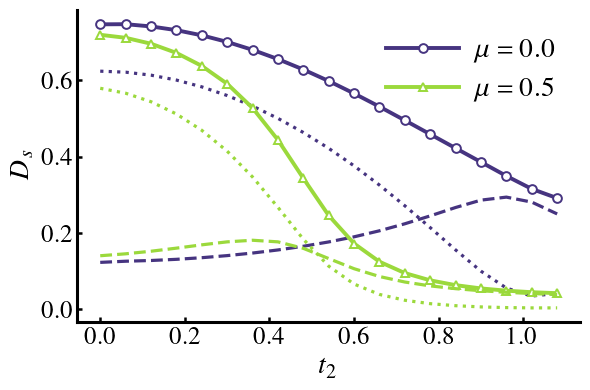

In [5]:
data = {}
for mu in mu_vals:
    Dtot_list, Dgeom_list, Dconv_list = [], [], []
    for t2 in t2_vals:
        Dtot, Dgeom, Dconv = integrate_stiffness(t2, mu, Delta, Nk=Nk)
        Dtot_list.append(Dtot)
        Dgeom_list.append(Dgeom)
        Dconv_list.append(Dconv)
    data[mu] = (np.array(Dtot_list), np.array(Dgeom_list), np.array(Dconv_list))

fig, ax = plt.subplots(figsize=(6, 4))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(mu_vals)))
markers = ["o", "^", "s", "D"]

for mu, c, m in zip(mu_vals, colors, markers):
    Dtot, Dgeom, Dconv = data[mu]

    ax.plot(
        t2_vals, Dtot,
        lw=2.8, color=c, marker=m, ms=6.3,
        markerfacecolor="white", markeredgewidth=1.4,
        label=rf"$\mu = {mu}$"
    )
    ax.plot(t2_vals, Dgeom, lw=2.3, color=c, ls="--")
    ax.plot(t2_vals, Dconv, lw=2.3, color=c, ls=":")

ax.set_xlabel(r"$t_2$")
ax.set_ylabel(r"$D_s$")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", handlelength=2.6)

fig.tight_layout()
plt.show()

In [6]:
def Ds_geom_k(k, t2, mu, Delta, eps_cut=1e-10):
    evals, evecs = np.linalg.eigh(ham(k, t2))
    vx = dH_dkx(k)
    vy = dH_dky(k)

    Ds_xx = 0.0
    Ds_yy = 0.0
    nb = len(evals)

    for n in range(nb):
        En = np.sqrt((evals[n] - mu)**2 + Delta**2)
        un = evecs[:, n]

        for m in range(nb):
            if m == n:
                continue

            Em = np.sqrt((evals[m] - mu)**2 + Delta**2)
            denom = evals[n] + evals[m] - 2 * mu

            if abs(denom) < eps_cut:
                continue

            pref = (1.0 / Em - 1.0 / En) * (evals[n] - evals[m]) / denom

            um = evecs[:, m]
            vx_nm = np.vdot(un, vx @ um)
            vy_nm = np.vdot(un, vy @ um)

            Ds_xx += pref * np.real(vx_nm * np.conj(vx_nm))
            Ds_yy += pref * np.real(vy_nm * np.conj(vy_nm))

    return float(np.real(Ds_xx + Ds_yy))


def integrate_geom_stiffness(t2, mu, Delta, Nk=60):
    kx_vals = np.linspace(-np.pi / a1[0], np.pi / a1[0], Nk)
    ky_vals = np.linspace(-np.pi / a2[1], np.pi / a2[1], Nk)

    total = 0.0
    for kx in kx_vals:
        for ky in ky_vals:
            k = np.array([kx, ky], dtype=float)
            total += Ds_geom_k(k, t2, mu, Delta)

    return (Delta**2) * total / Nk**2 / (2 * np.pi)**2

In [8]:
Nk = 60
Delta = 0.16
t2_vals = np.linspace(0.0, 1.08, 19)
mu_vals = [0.0, -1.25, 0.5]

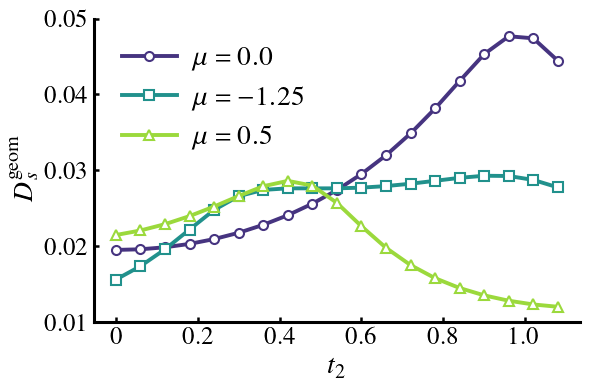

In [9]:
results = {}

for mu in mu_vals:
    Ds_mu = []
    for t2 in t2_vals:
        Ds_mu.append(integrate_geom_stiffness(t2, mu, Delta, Nk=Nk))
    results[mu] = np.array(Ds_mu)

fig, ax = plt.subplots(figsize=(6, 4))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(mu_vals)))
markers = ["o", "s", "^", "D"]

for (mu, Ds), c, m in zip(results.items(), colors, markers):
    ax.plot(
        t2_vals, Ds,
        lw=2.8,
        marker=m,
        ms=6.5,
        color=c,
        markerfacecolor="white",
        markeredgewidth=1.5,
        label=rf"$\mu = {mu}$"
    )

ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels([r"$0$", r"$0.2$", r"$0.4$", r"$0.6$", r"$0.8$", r"$1.0$"])

ax.set_yticks([0.01, 0.02, 0.03, 0.04, 0.05])
ax.set_yticklabels([r"$0.01$", r"$0.02$", r"$0.03$", r"$0.04$", r"$0.05$"])

ax.set_xlabel(r"$t_2$")
ax.set_ylabel(r"$D_s^{\mathrm{geom}}$")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
# plt.savefig("images/Ds_quantum_metric.pdf")
plt.show()